# Knot Propagator

This notebook generate optical knotty fields and propagates them through space.

In [1]:
import numpy as np 
from scipy.fft import fft2, ifft2, fftshift, ifftshift

import yaml 
from yaml import Loader

import matplotlib.pyplot as plt 
import os 

from optical_functions import cart2pol, setKnotType, norm_field, TotInt
from knot_funcs import propTF, propTF_C, PropKnots, Singular, KnotPlot

import plotly
import plotly.graph_objs as go

# CONSTANTS 

cm = 1e-2
mm = 1e-3
um = 1e-6
nm = 1e-9

Load simulation parameters 

In [28]:
stream = open("configs/simKnot.yaml", 'r')
cnfg = yaml.load(stream, Loader=Loader)

knotType = cnfg['knotType'] # The type of knot to propagate 
shapeParams = cnfg['shapeParams'] # The shape parameters of our knot 
w0 = cnfg['w0']*mm # beam width of knot (in mm)
z0 = cnfg['z0']*cm # distance from z=0 cm by which we should propagate the knot (in the forwards and backwards directions)
nz = cnfg['nz'] # number of phase planes to "measure" within the propagation path 

initialize field

In [29]:
la=0.78*um
k = (2*np.pi)/la
N=128
maxx = 20*um*N

# Space definition 
dx = maxx/N 
dy = maxx/N
h = dx
X = dx*(np.arange(N) - N //2)
Y = dy*(np.arange(N) - N //2)
xx,yy=np.meshgrid(X,Y)
r, phi= cart2pol(xx,yy)

Create knot field at z=0 and plot intensity and phase of the field

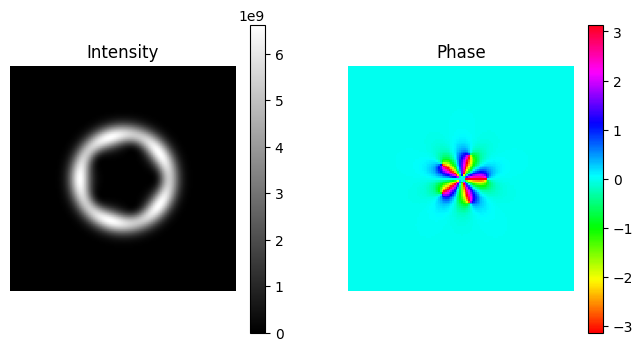

In [30]:
field = setKnotType(r, phi, w0, knotType, shapeParams)
TotInt(field)

Normalize the field 

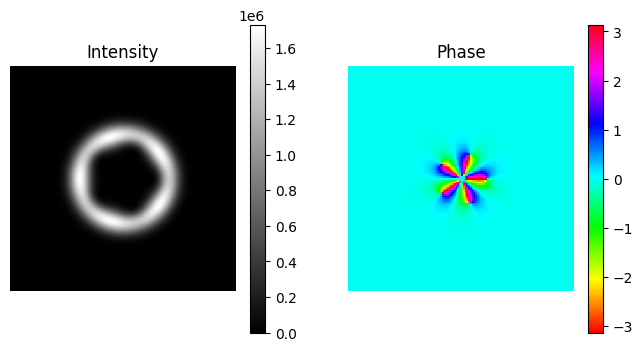

In [31]:
normy_field = norm_field(field, h)
TotInt(normy_field)

Now propagate the knot up to a certain, pre-defined distance. We investigate two implementations of the Fresnel Propagator

In [32]:
FB = PropKnots(z0, nz, normy_field, maxx, la, False, compress_len=64, system_C=False, X=xx, Y=yy) # Backwards propagation direction 
F = PropKnots(z0, nz, normy_field, maxx, la, True, compress_len=64, system_C=False, X=xx, Y=yy) # Forwards propagation direction 

# Swap the elements of the backwards propagating array s.t. the field at z=0 is at the end

temp = FB.copy()
for i in range(len(FB)):
    FB[i] = temp[len(FB)-1-i]

# Store forward/backwards propagated beams onto a single array. 
TP = np.concatenate((FB,F))

0.027586206896551727
 INITIATING BACKWARD PROPAGATION 
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
0.027586206896551727
 INITIATING FORWARD PROPAGATION 
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29


Now compute and plot the singularities

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60


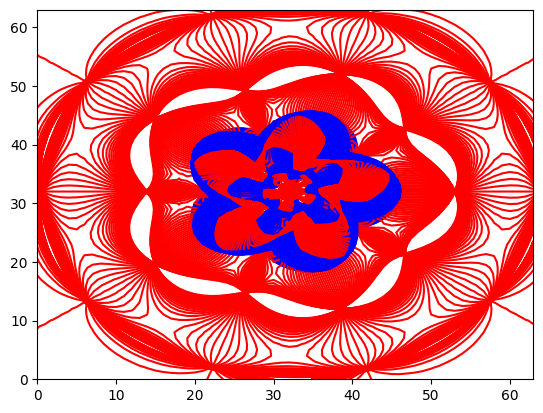

In [33]:
# Now compute and plot the singularities with contour filtering
# The plotted singularities are scaled in the z-direction by a factor of 2 
# min_contour_length filters out small noisy contours

min_contour_length = 20  # Adjust this value to filter more/less aggressively

sing = Singular(TP, True, min_contour_length=min_contour_length)
KnotPlot(sing, 3)

Also, create an animation of the propagated knot fields

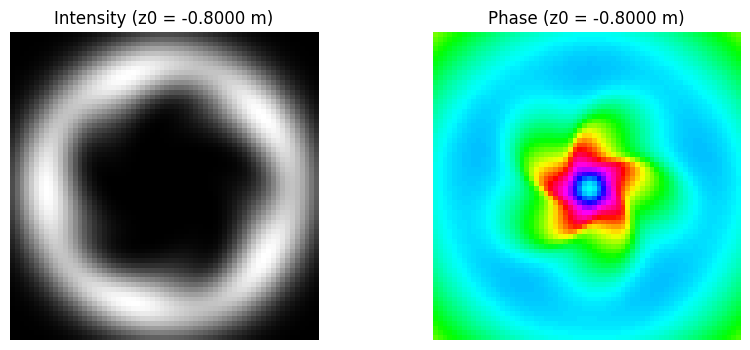

In [34]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Create the figure and axes
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Create symmetric Z0 interval 
z0_int = np.linspace(-z0,z0, len(TP))

def animate(frame):
    # Clear previous plots
    ax[0].clear()
    ax[1].clear()
    
    # Get the field at the current propagation plane
    Ex = TP[frame]
    
    # Plot intensity with limited precision (e.g., 4 decimal places)
    ax[0].set_title(f'Intensity (z0 = {z0_int[frame]:.4f} m)')
    intensity = ax[0].imshow(abs(Ex)**2, cmap="gist_gray")
    ax[0].axis('off')
    
    # Plot phase
    ax[1].set_title(f'Phase (z0 = {z0_int[frame]:.4f} m)')
    phase = ax[1].imshow(np.angle(Ex), cmap="hsv", interpolation='nearest')
    ax[1].axis('off')
    
    return ax

# Create animation
anim = FuncAnimation(fig, animate, frames=len(TP), interval=100, repeat=True)

# Save the animation (uncomment one of the options below):
# Option 1: Save as MP4 (requires ffmpeg)
# anim.save('knot_propagation.mp4', writer='ffmpeg', fps=10, dpi=100)

# Option 2: Save as GIF (requires pillow)
anim.save(f'knot_propagation_{knotType}.gif', writer='pillow', fps=10, dpi=100)

# Display in notebook
HTML(anim.to_jshtml())
